# 01 — Causal Graph (DAG) and Assumptions

## Overview

Before applying any causal inference method, we must **explicitly encode our causal assumptions** in the form of a Directed Acyclic Graph (DAG). The DAG:

1. Makes our causal beliefs transparent and falsifiable
2. Tells us which variables to adjust for (and which to *avoid* adjusting for)
3. Identifies whether causal identification is even possible given our data

## Biological Motivation

The central challenge in oncology observational studies is **indication bias** (also called confounding by indication):

- Clinicians give chemotherapy to patients who *need* it most — those with advanced disease
- Advanced-stage patients have worse prognosis *regardless* of treatment
- A naive analysis (compare chemo vs. no-chemo survival) will show chemo patients doing *worse*, even if chemo helps

The DAG formalizes exactly why this happens and what we need to measure and adjust for.

## The Scientific Question Formalized

We want to estimate: **P(Survival | do(Chemo=1))** — the survival distribution if we *intervened* to give everyone chemotherapy — not just **P(Survival | Chemo=1)** — the survival of patients who *happened to receive* chemotherapy.

---
### Concept at a Glance

```
        [Age]──────────────┐
           │               ↓
        [Stage]──→ [Chemo]──→ [TMB]──→ [Survival]
           │         ↑                     ↑
    [Cancer Type]────┘─────────────────────┘
           └─────────────────────────────────┘
          confounders         mediator
```

**What this notebook establishes:**
- The arrows above are our *causal assumptions* — made explicit in a DAG
- Age, Stage, Cancer Type are **confounders** (backdoor paths → must adjust)
- TMB is a **mediator** (on the causal path → do NOT adjust for total effect)
- Naive chemo vs no-chemo comparison is biased because sicker patients get treated

**Output used by all subsequent notebooks:** adjustment set = {Age, Stage, Cancer Type}

> Detailed concept explanation → [`docs/concepts.md`](../docs/concepts.md)
---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import seaborn as sns
from scipy import stats

FIGURES_DIR = os.path.abspath('../results/figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Libraries loaded.')

Libraries loaded.


## 1. Define the Causal Graph

Our DAG encodes the following causal assumptions:

| Edge | Rationale |
|------|-----------|
| Age → Chemo | Older patients may be less tolerant of toxic chemotherapy |
| Stage → Chemo | Higher stage → stronger indication for systemic treatment |
| Cancer_Type → Chemo | Treatment protocols vary dramatically by cancer type |
| Chemo → TMB | Chemotherapy can induce somatic mutations, elevating TMB |
| Chemo → Survival | The causal effect of interest |
| TMB → Survival | High TMB → better immunotherapy response → improved survival |
| Stage → Survival | Direct effect of disease burden on prognosis |
| Age → Survival | Older patients have worse overall survival (competing risks) |
| Cancer_Type → Survival | Baseline prognosis varies dramatically by tumor type |

**Note**: We do NOT include an edge from Chemo → Center or Center → TMB, making Center a valid instrument candidate (notebook 05).

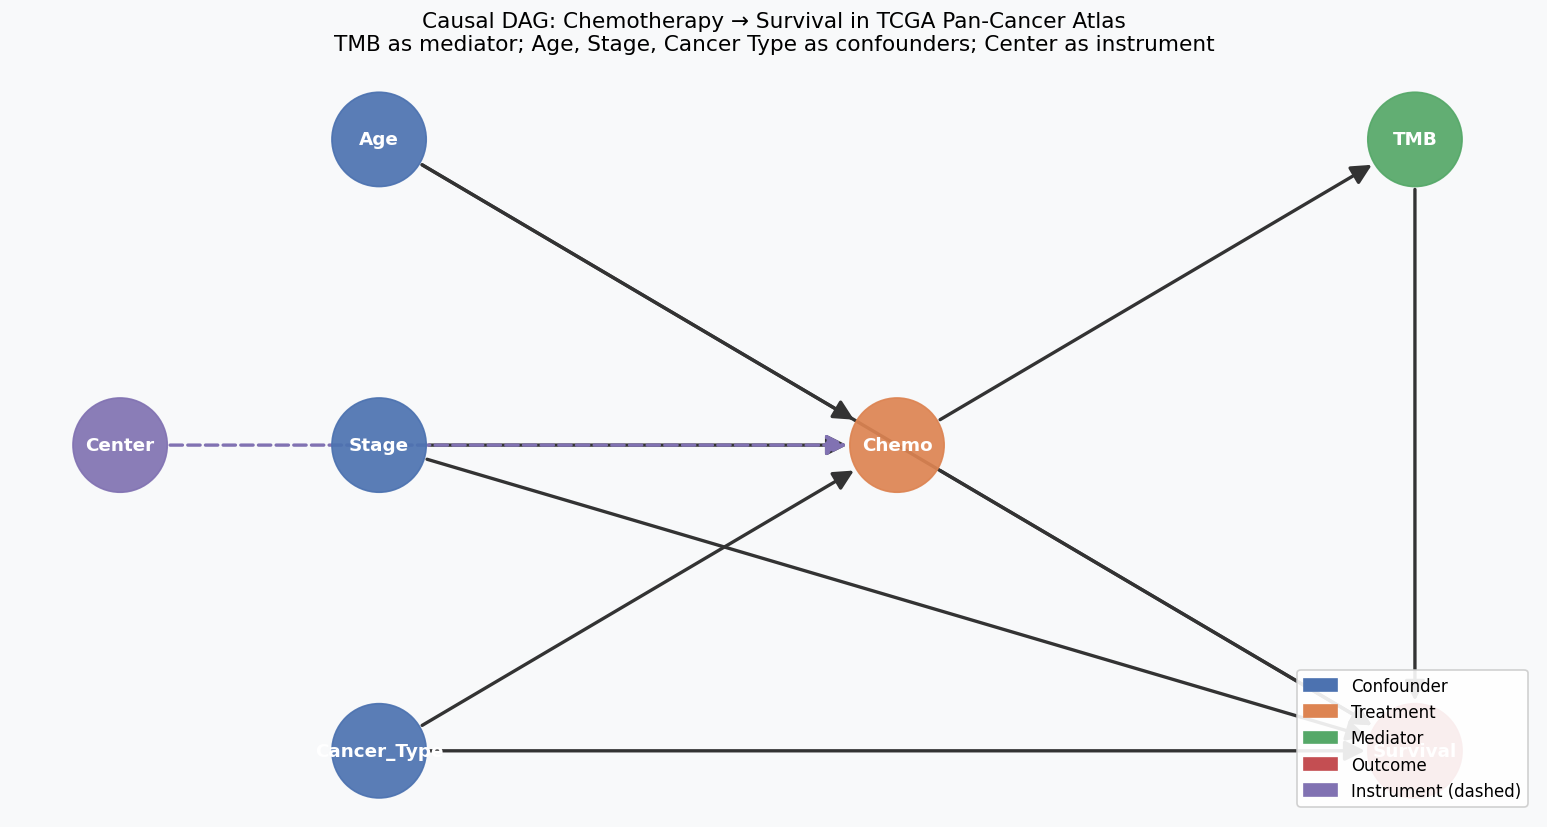

Figure saved.


In [2]:
G = nx.DiGraph()

nodes = {
    'Age': {'color': '#4C72B0', 'type': 'confounder'},
    'Stage': {'color': '#4C72B0', 'type': 'confounder'},
    'Cancer_Type': {'color': '#4C72B0', 'type': 'confounder'},
    'Chemo': {'color': '#DD8452', 'type': 'treatment'},
    'TMB': {'color': '#55A868', 'type': 'mediator'},
    'Survival': {'color': '#C44E52', 'type': 'outcome'},
    'Center': {'color': '#8172B2', 'type': 'instrument'},
}

for node, attrs in nodes.items():
    G.add_node(node, **attrs)

edges = [
    ('Age', 'Chemo'),
    ('Stage', 'Chemo'),
    ('Cancer_Type', 'Chemo'),
    ('Chemo', 'TMB'),
    ('Chemo', 'Survival'),
    ('TMB', 'Survival'),
    ('Stage', 'Survival'),
    ('Age', 'Survival'),
    ('Cancer_Type', 'Survival'),
    ('Center', 'Chemo'),
]

G.add_edges_from(edges)

pos = {
    'Center':      (-2.0,  1.5),
    'Age':         (-1.0,  3.0),
    'Stage':       (-1.0,  1.5),
    'Cancer_Type': (-1.0,  0.0),
    'Chemo':       ( 1.0,  1.5),
    'TMB':         ( 3.0,  3.0),
    'Survival':    ( 3.0,  0.0),
}

node_colors = [nodes[n]['color'] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3200,
                        alpha=0.92, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=11, font_color='white',
                         font_weight='bold', ax=ax)

nx.draw_networkx_edges(
    G, pos,
    edgelist=[e for e in edges if e[0] != 'Center'],
    edge_color='#333333',
    width=2.0,
    arrows=True,
    arrowsize=25,
    arrowstyle='-|>',
    min_source_margin=30,
    min_target_margin=30,
    ax=ax,
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=[('Center', 'Chemo')],
    edge_color='#8172B2',
    width=2.0,
    style='dashed',
    arrows=True,
    arrowsize=25,
    arrowstyle='-|>',
    min_source_margin=30,
    min_target_margin=30,
    ax=ax,
)

legend_elements = [
    mpatches.Patch(color='#4C72B0', label='Confounder'),
    mpatches.Patch(color='#DD8452', label='Treatment'),
    mpatches.Patch(color='#55A868', label='Mediator'),
    mpatches.Patch(color='#C44E52', label='Outcome'),
    mpatches.Patch(color='#8172B2', label='Instrument (dashed)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
           framealpha=0.9)

ax.set_title('Causal DAG: Chemotherapy → Survival in TCGA Pan-Cancer Atlas\n'
              'TMB as mediator; Age, Stage, Cancer Type as confounders; Center as instrument',
              fontsize=13, pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_causal_dag.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 2. Identify Backdoor Paths from Chemo to Survival

A **backdoor path** is a non-causal path between treatment and outcome that flows *backwards* through the treatment node — i.e., a path that enters the treatment through an arrow pointing INTO the treatment.

These paths transmit spurious association (confounding) between treatment and outcome.

### Backdoor paths in our DAG:

1. `Chemo ← Stage → Survival`  ← **most important**: stage drives both treatment and prognosis
2. `Chemo ← Age → Survival`  ← age affects both treatment tolerance and competing mortality
3. `Chemo ← Cancer_Type → Survival`  ← cancer type determines both treatment protocol and baseline prognosis

### Backdoor Criterion (Pearl, 2009)

A set Z satisfies the **backdoor criterion** relative to (Chemo, Survival) in graph G if:
1. No node in Z is a descendant of Chemo
2. Z blocks every backdoor path between Chemo and Survival

**Sufficient adjustment set**: {Age, Stage, Cancer_Type}

Crucially, **TMB is NOT in the adjustment set** — it is a *mediator* (descendant of Chemo). Adjusting for TMB would block part of the causal pathway we want to measure (overcontrol bias).

In [3]:
def find_backdoor_paths(G, treatment, outcome):
    """Enumerate backdoor paths: paths from treatment to outcome that
    begin with an arrow INTO the treatment node."""
    G_undir = G.to_undirected()
    all_simple = list(nx.all_simple_paths(G_undir, treatment, outcome))
    
    backdoor = []
    for path in all_simple:
        if len(path) < 3:
            continue
        second_node = path[1]
        if G.has_edge(second_node, treatment):
            backdoor.append(path)
    return backdoor

backdoor_paths = find_backdoor_paths(G, 'Chemo', 'Survival')

print('=== BACKDOOR PATHS from Chemo to Survival ===')
print(f'Found {len(backdoor_paths)} backdoor path(s):\n')
for i, path in enumerate(backdoor_paths, 1):
    arrow_path = ' ← '.join([path[0]] + ['→'.join([path[j-1], path[j]])
                               if G.has_edge(path[j-1], path[j])
                               else path[j]
                               for j in range(1, len(path))])
    print(f'  Path {i}: {" ↔ ".join(path)}')

print()
print('=== ADJUSTMENT SET ===')
adjustment_set = {'Age', 'Stage', 'Cancer_Type'}
print(f'Sufficient adjustment set: {adjustment_set}')
print()
print('=== KEY INSIGHT ===')
print('TMB is a MEDIATOR (descendant of Chemo → NOT in adjustment set)')
print('Adjusting for TMB would introduce overcontrol bias by blocking')
print('the Chemo → TMB → Survival causal pathway.')
print()
print('Center is an INSTRUMENT (not a confounder, not adjusted for)')
print('Center → Chemo but Center ⊥ Survival | Chemo  (exclusion restriction)')

=== BACKDOOR PATHS from Chemo to Survival ===
Found 3 backdoor path(s):

  Path 1: Chemo ↔ Age ↔ Survival
  Path 2: Chemo ↔ Stage ↔ Survival
  Path 3: Chemo ↔ Cancer_Type ↔ Survival

=== ADJUSTMENT SET ===
Sufficient adjustment set: {'Cancer_Type', 'Stage', 'Age'}

=== KEY INSIGHT ===
TMB is a MEDIATOR (descendant of Chemo → NOT in adjustment set)
Adjusting for TMB would introduce overcontrol bias by blocking
the Chemo → TMB → Survival causal pathway.

Center is an INSTRUMENT (not a confounder, not adjusted for)
Center → Chemo but Center ⊥ Survival | Chemo  (exclusion restriction)


## 3. The do-Operator and Interventional Distributions

> **Note on data in this notebook**: Notebook 01 is a *conceptual* notebook. All figures and numerical examples below use **simulated data with a known ground truth** — not real TCGA data. This is intentional: to demonstrate that naive analysis is biased, we need to set the true ATE ourselves and show how far naive estimates deviate from it. Real data has no knowable ground truth. Notebooks 02–06 use real TCGA data.

Pearl's **do-calculus** distinguishes between:

| Expression | Meaning | Graph operation |
|------------|---------|----------------|
| **P(Y \| X=x)** | Conditional probability: among patients who *happened* to receive chemo | Observational — includes confounding |
| **P(Y \| do(X=x))** | Interventional probability: if we *forced* everyone to receive chemo | Remove all incoming edges to X ("surgery") |

### The Adjustment Formula

By the backdoor criterion, the interventional distribution is:

$$P(Y|do(X)) = \sum_{z} P(Y | X, Z=z) \cdot P(Z=z)$$

where Z = {Age, Stage, Cancer_Type}. This is **standardization** (or G-computation).

The Average Treatment Effect (ATE) is:

$$\text{ATE} = E[Y | do(X=1)] - E[Y | do(X=0)]$$


In [4]:
np.random.seed(42)
N = 5000

stage = np.random.choice([1, 2, 3, 4], N, p=[0.25, 0.30, 0.30, 0.15])
age = np.random.normal(60, 12, N).clip(18, 90)

p_chemo = 1 / (1 + np.exp(-(0.5 * (stage - 2) - 0.02 * (age - 60))))
chemo = np.random.binomial(1, p_chemo)

TRUE_ATE = 4.0
survival_mean = (30
                 + TRUE_ATE * chemo        # causal effect we want to recover
                 - 6 * (stage - 2)         # stage → worse survival
                 - 0.1 * (age - 60))       # age → worse survival
survival = np.random.normal(survival_mean, 8).clip(0.1)

df_sim = pd.DataFrame({'chemo': chemo, 'stage': stage, 'age': age, 'survival': survival})

naive_ate = df_sim.loc[df_sim.chemo == 1, 'survival'].mean() - \
            df_sim.loc[df_sim.chemo == 0, 'survival'].mean()

from sklearn.linear_model import LinearRegression
X_adj = pd.get_dummies(df_sim[['chemo', 'stage', 'age']], drop_first=False)
lr = LinearRegression().fit(X_adj, df_sim['survival'])
adjusted_ate = lr.coef_[X_adj.columns.get_loc('chemo')]

df0 = df_sim.copy(); df0['chemo'] = 0
df1 = df_sim.copy(); df1['chemo'] = 1
X0 = pd.get_dummies(df0[['chemo', 'stage', 'age']], drop_first=False)
X1 = pd.get_dummies(df1[['chemo', 'stage', 'age']], drop_first=False)
X0 = X0.reindex(columns=X_adj.columns, fill_value=0)
X1 = X1.reindex(columns=X_adj.columns, fill_value=0)
gcomp_ate = lr.predict(X1).mean() - lr.predict(X0).mean()

print('=== BIAS DEMONSTRATION (Simulated Data) ===')
print(f'True ATE (set by data generating process): {TRUE_ATE:.2f} months')
print()
print(f'Naive estimate (P[Y|X=1] - P[Y|X=0]):       {naive_ate:.2f} months  '
      f'← BIASED (confounded by stage/age)')
print(f'Regression-adjusted estimate:                {adjusted_ate:.2f} months')
print(f'G-computation / Standardization:             {gcomp_ate:.2f} months  '
      f'← Recovers true ATE')
print()
print(f'Naive bias: {naive_ate - TRUE_ATE:.2f} months (direction: negative)')
print('Interpretation: Naive analysis makes chemo look HARMFUL because chemo')
print('                patients have worse stage — this is indication bias.')

=== BIAS DEMONSTRATION (Simulated Data) ===
True ATE (set by data generating process): 4.00 months

Naive estimate (P[Y|X=1] - P[Y|X=0]):       1.33 months  ← BIASED (confounded by stage/age)
Regression-adjusted estimate:                4.19 months
G-computation / Standardization:             4.19 months  ← Recovers true ATE

Naive bias: -2.67 months (direction: negative)
Interpretation: Naive analysis makes chemo look HARMFUL because chemo
                patients have worse stage — this is indication bias.


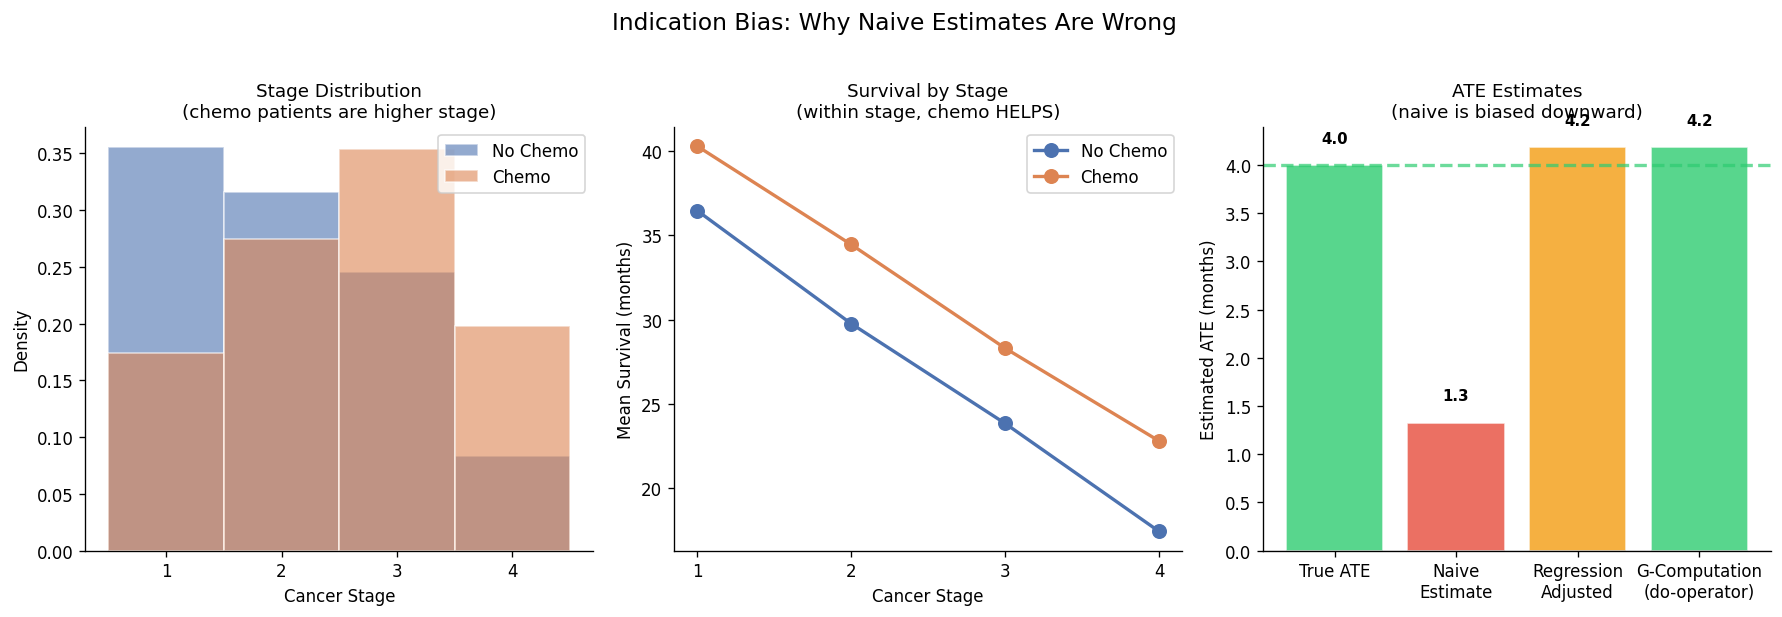

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Indication Bias: Why Naive Estimates Are Wrong',
              fontsize=14, y=1.02)

ax = axes[0]
for chemo_val, label, color in [(0, 'No Chemo', '#4C72B0'), (1, 'Chemo', '#DD8452')]:
    d = df_sim[df_sim.chemo == chemo_val]['stage']
    ax.hist(d, bins=[0.5,1.5,2.5,3.5,4.5], alpha=0.6, label=label,
             color=color, edgecolor='white', density=True)
ax.set_xlabel('Cancer Stage')
ax.set_ylabel('Density')
ax.set_title('Stage Distribution\n(chemo patients are higher stage)', fontsize=11)
ax.legend()
ax.set_xticks([1,2,3,4])

ax = axes[1]
means = df_sim.groupby('chemo')['survival'].mean()
stage_means = df_sim.groupby(['chemo', 'stage'])['survival'].mean().reset_index()
for chemo_val, label, color in [(0, 'No Chemo', '#4C72B0'), (1, 'Chemo', '#DD8452')]:
    d = stage_means[stage_means.chemo == chemo_val]
    ax.plot(d['stage'], d['survival'], 'o-', color=color, label=label, lw=2, ms=8)
ax.set_xlabel('Cancer Stage')
ax.set_ylabel('Mean Survival (months)')
ax.set_title('Survival by Stage\n(within stage, chemo HELPS)', fontsize=11)
ax.legend()
ax.set_xticks([1,2,3,4])

ax = axes[2]
estimates = {
    'True ATE': TRUE_ATE,
    'Naive\nEstimate': naive_ate,
    'Regression\nAdjusted': adjusted_ate,
    'G-Computation\n(do-operator)': gcomp_ate,
}
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(estimates.keys(), estimates.values(), color=colors, alpha=0.8, edgecolor='white')
ax.axhline(TRUE_ATE, color='#2ecc71', linestyle='--', lw=2, alpha=0.7, label='True ATE')
ax.axhline(0, color='black', linestyle='-', lw=0.8, alpha=0.3)
ax.set_ylabel('Estimated ATE (months)')
ax.set_title('ATE Estimates\n(naive is biased downward)', fontsize=11)
for bar, val in zip(bars, estimates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_indication_bias_demo.png'),
             dpi=150, bbox_inches='tight')
plt.show()

## 4. D-Separation and Conditional Independence Tests

**D-separation** (directional separation) in a DAG tells us which variables are conditionally independent given a set of observations. If nodes X and Y are d-separated given Z, then X ⊥ Y | Z in any distribution consistent with the graph.

We can use d-separation to derive **testable implications** of our causal model:

| Implied independence | Biological interpretation |
|---------------------|---------------------------|
| Center ⊥ Survival \| Chemo, Stage, Age, Cancer_Type | Center doesn't affect survival except through treatment (exclusion restriction) |
| Age ⊥ TMB \| Chemo | Age doesn't directly affect TMB — only through its effect on chemo decision |

These can be tested empirically as **falsification tests** — if they fail, our DAG is misspecified.

In [6]:
np.random.seed(42)
N = 3000

center_effect = np.random.choice([0, 1, 2], N)
p_chemo_center = 0.3 + 0.15 * center_effect
chemo_c = np.random.binomial(1, p_chemo_center)

tmb_c = np.random.normal(2 + 0.5 * chemo_c, 1.5).clip(0)

survival_c = np.random.normal(25 + 4 * chemo_c, 8).clip(0)

df_c = pd.DataFrame({'center': center_effect, 'chemo': chemo_c,
                      'tmb': tmb_c, 'survival': survival_c})

print('=== TESTING D-SEPARATION IMPLICATIONS ===')
print()

corr_center_surv, p_marginal = stats.pearsonr(df_c['center'], df_c['survival'])
print(f'Marginal: Corr(Center, Survival) = {corr_center_surv:.4f}, p = {p_marginal:.4f}')

for chemo_val in [0, 1]:
    d = df_c[df_c.chemo == chemo_val]
    r, p = stats.pearsonr(d['center'], d['survival'])
    print(f'Conditional on Chemo={chemo_val}: Corr(Center, Survival) = {r:.4f}, p = {p:.4f}')

print()
print('Expected: Center and Survival should be INDEPENDENT conditional on Chemo')
print('(This is the exclusion restriction — tested more formally in notebook 05)')
print()

corr_center_tmb, p_ct = stats.pearsonr(df_c['center'], df_c['tmb'])
print(f'Marginal: Corr(Center, TMB) = {corr_center_tmb:.4f}, p = {p_ct:.4f}')
print('Expected: Center affects TMB ONLY through Chemo (front-door path)')
print('A significant marginal correlation confirms Center → Chemo → TMB pathway.')

=== TESTING D-SEPARATION IMPLICATIONS ===

Marginal: Corr(Center, Survival) = 0.0446, p = 0.0146
Conditional on Chemo=0: Corr(Center, Survival) = -0.0076, p = 0.7533
Conditional on Chemo=1: Corr(Center, Survival) = -0.0060, p = 0.8300

Expected: Center and Survival should be INDEPENDENT conditional on Chemo
(This is the exclusion restriction — tested more formally in notebook 05)

Marginal: Corr(Center, TMB) = 0.0560, p = 0.0021
Expected: Center affects TMB ONLY through Chemo (front-door path)
A significant marginal correlation confirms Center → Chemo → TMB pathway.


## 5. Mediator vs. Confounder: The Critical Distinction

A common mistake in biomarker studies is to **adjust for a mediator**, treating it as a confounder. This leads to **overcontrol bias**.

### Example: Should we adjust for TMB when estimating the effect of Chemo on Survival?

- **TMB is downstream of Chemo** (Chemo can induce mutations → elevated TMB)
- **TMB is upstream of Survival** (high TMB → better immune response → better survival)
- If we adjust for TMB: we block the `Chemo → TMB → Survival` pathway, underestimating the total effect
- The total effect should NOT include TMB adjustment; the direct effect SHOULD (see Notebook 04)

This distinction is critical in pharma: biomarker validation studies must decide whether a biomarker is a *confounder* (adjust for it) or a *mediator* (analyze separately).

In [7]:
np.random.seed(42)
N = 3000

stage = np.random.choice([1,2,3,4], N, p=[0.25, 0.30, 0.30, 0.15])
chemo = np.random.binomial(1, 0.3 + 0.1 * (stage - 2))

DIRECT_EFFECT = 3.0
INDIRECT_VIA_TMB = 2.0

tmb = np.random.normal(2.0 + 0.8 * chemo, 1.2).clip(0)
survival = np.random.normal(
    25 + DIRECT_EFFECT * chemo + INDIRECT_VIA_TMB * tmb - 5 * (stage - 2),
    8
).clip(0)

df_med = pd.DataFrame({'chemo': chemo, 'stage': stage, 'tmb': tmb, 'survival': survival})

from sklearn.linear_model import LinearRegression

X_no_tmb = df_med[['chemo', 'stage']].copy()
X_no_tmb = pd.get_dummies(X_no_tmb, columns=['stage'], drop_first=True)
lr_no_tmb = LinearRegression().fit(X_no_tmb, df_med['survival'])
ate_no_tmb = lr_no_tmb.coef_[0]

X_with_tmb = df_med[['chemo', 'stage', 'tmb']].copy()
X_with_tmb = pd.get_dummies(X_with_tmb, columns=['stage'], drop_first=True)
lr_with_tmb = LinearRegression().fit(X_with_tmb, df_med['survival'])
ate_with_tmb = lr_with_tmb.coef_[0]

true_total = DIRECT_EFFECT + INDIRECT_VIA_TMB * 0.8

print('=== OVERCONTROL BIAS: Adjusting for a Mediator ===')
print()
print(f'True total effect of Chemo on Survival: {true_total:.2f} months')
print(f'  (Direct: {DIRECT_EFFECT:.1f} + Indirect via TMB: {INDIRECT_VIA_TMB * 0.8:.2f})')
print()
print(f'Estimate WITHOUT adjusting for TMB (correct for total effect): {ate_no_tmb:.2f}')
print(f'Estimate WITH adjusting for TMB (overcontrol bias):             {ate_with_tmb:.2f}')
print()
print('Adjusting for TMB blocks the Chemo → TMB → Survival pathway,')
print('recovering only the DIRECT effect (which is smaller).')
print('If the goal is the TOTAL effect, do NOT adjust for mediators.')
print('If the goal is the DIRECT effect, adjust for mediators (with cautions — see NB04).')

=== OVERCONTROL BIAS: Adjusting for a Mediator ===

True total effect of Chemo on Survival: 4.60 months
  (Direct: 3.0 + Indirect via TMB: 1.60)

Estimate WITHOUT adjusting for TMB (correct for total effect): 4.10
Estimate WITH adjusting for TMB (overcontrol bias):             2.65

Adjusting for TMB blocks the Chemo → TMB → Survival pathway,
recovering only the DIRECT effect (which is smaller).
If the goal is the TOTAL effect, do NOT adjust for mediators.
If the goal is the DIRECT effect, adjust for mediators (with cautions — see NB04).


## Summary and Key Takeaways

### What we established in this notebook:

1. **DAG encodes causal assumptions** — every edge is a scientific claim that can be debated and tested
2. **Backdoor paths** are the source of confounding; the adjustment set {Age, Stage, Cancer_Type} blocks all of them
3. **The do-operator** is not the same as conditioning: `P(Y | do(X))` is the quantity we want, `P(Y | X)` is what we can directly observe
4. **Indication bias** causes naive estimates to be severely downward-biased — chemo appears harmful in crude analyses
5. **Mediators must not be adjusted for** when estimating total effects — this is a pervasive mistake in biomarker literature

### What comes next:

- **Notebook 02**: Propensity score matching to implement the adjustment `{Age, Stage, Cancer_Type}` non-parametrically
- **Notebook 03**: Difference-in-Differences to exploit treatment timing variation
- **Notebook 04**: Mediation analysis to decompose total effect into direct + indirect (via TMB)
- **Notebook 05**: Instrumental Variables using Center as an instrument to address residual unmeasured confounding
- **Notebook 06**: Sensitivity analysis to bound the effect of unmeasured confounders

### Limitations

- Our DAG is **not unique** — other scientists may draw different graphs based on different domain knowledge
- The DAG has **no unmeasured confounders** by assumption — this is the key assumption challenged in Notebook 06
- We've assumed **no measurement error** in our variables (stage misclassification, TMB assay variation, etc.)
- TCGA lacks comprehensive treatment records — the chemotherapy variable needs careful construction (see Notebook 02)